Pipeline running for Subject 09
Cycle 20 | Ankle RMSE: 0.1654 | Latency: 12.06ms
Cycle 40 | Ankle RMSE: 0.2075 | Latency: 10.29ms
Cycle 60 | Ankle RMSE: 0.1732 | Latency: 11.31ms
Cycle 80 | Ankle RMSE: 0.1691 | Latency: 11.46ms
Cycle 100 | Ankle RMSE: 0.1557 | Latency: 11.79ms
Cycle 120 | Ankle RMSE: 0.1800 | Latency: 11.31ms
Cycle 140 | Ankle RMSE: 0.1739 | Latency: 9.70ms
Cycle 160 | Ankle RMSE: 0.1796 | Latency: 10.25ms
Cycle 180 | Ankle RMSE: 0.1873 | Latency: 11.83ms
Cycle 200 | Ankle RMSE: 0.1822 | Latency: 10.11ms
Cycle 220 | Ankle RMSE: 0.1888 | Latency: 10.56ms
Cycle 240 | Ankle RMSE: 0.1827 | Latency: 10.83ms
Cycle 260 | Ankle RMSE: 0.1828 | Latency: 16.83ms
Cycle 280 | Ankle RMSE: 0.1779 | Latency: 10.80ms
Cycle 300 | Ankle RMSE: 0.1824 | Latency: 10.72ms
Cycle 320 | Ankle RMSE: 0.1793 | Latency: 12.02ms
Cycle 340 | Ankle RMSE: 0.1774 | Latency: 12.05ms
Cycle 360 | Ankle RMSE: 0.1759 | Latency: 10.61ms
Cycle 380 | Ankle RMSE: 0.1752 | Latency: 12.03ms
Cycle 400 | Ankle RMSE:

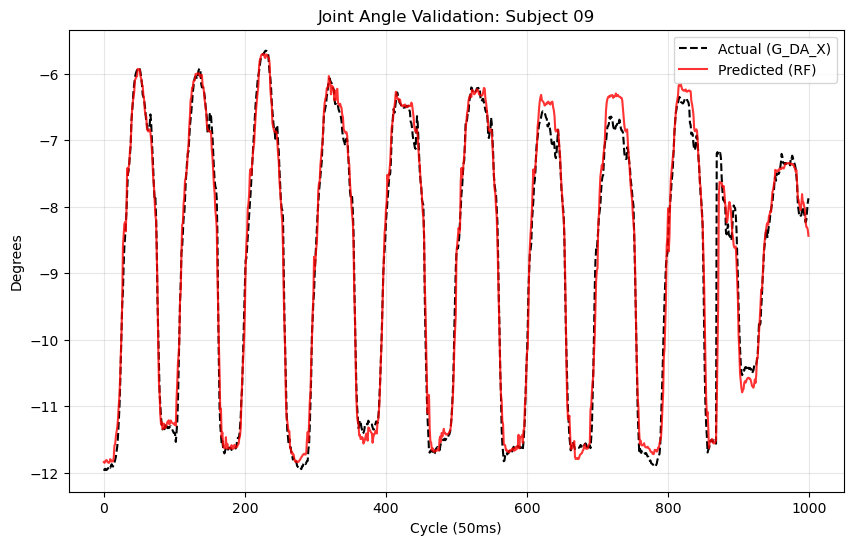

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import time
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

class ControlSystem:
    def __init__(self, subject_id="09", window_size=410, step_size=102):
        self.subject_id = subject_id
        self.window_size = window_size
        self.step_size = step_size
        self.current_idx = 0
        
        self.history_pred = []
        self.history_truth = []
        self.all_errors = []

        # Load serialized regressor
        model_path = Path(f"regressor_{self.subject_id}.pkl")
        if not model_path.exists():
            raise FileNotFoundError(f"Model not found at {model_path}")
        self.regressor = joblib.load(model_path)
        
        # Initialize data stream
        base_dir = Path.cwd()
        data_path = base_dir.parent / "Data" / f"{self.subject_id}_filtered_all_data.pkl"
        full_df = pd.read_pickle(data_path)
        
        # Define target mapping for goniometers
        self.target_mapping = [c for c in full_df.columns if c.startswith("G_")]
        
        # Split final 20% for simulation
        clean_df = full_df[~full_df['Activity'].str.endswith('_')].copy()
        split_idx = int(len(clean_df) * 0.8)
        self.test_raw = clean_df.iloc[split_idx:].reset_index(drop=True)
        
        # Define sensor column groups
        self.ta_cols = [c for c in clean_df.columns if "EMG_TA" in c]
        self.gm_cols = [c for c in clean_df.columns if "EMG_GM" in c]
        self.imu_cols = [c for c in clean_df.columns if any(s in c for s in ["-f", "-c", "-q", "-h"])]

    def get_data(self):
        # Fetch sliding window and ground truth
        if self.current_idx + self.window_size > len(self.test_raw):
            return None, None, None, None
            
        window = self.test_raw.iloc[self.current_idx : self.current_idx + self.window_size]
        
        raw_ta = window[self.ta_cols].to_numpy().astype(np.float64)
        raw_gm = window[self.gm_cols].to_numpy().astype(np.float64)
        raw_imu = window[self.imu_cols].to_numpy().astype(np.float64)
        ground_truth = window[self.target_mapping].iloc[-1].to_numpy()
        
        return raw_ta, raw_gm, raw_imu, ground_truth

    def preprocess_signals(self, raw_ta, raw_gm, raw_imu):
        # Passthrough to match training signal distribution
        return raw_ta, raw_gm, raw_imu

    def extract_features(self, ta, gm, imu):
        # Calculate MAV and IMU arithmetic means
        feat_ta_mav = np.mean(np.abs(ta))
        feat_gm_mav = np.mean(np.abs(gm))
        feat_imu_means = np.mean(imu, axis=0).tolist()
        return np.array([feat_ta_mav, feat_gm_mav] + feat_imu_means).reshape(1, -1)

    def validate_prediction(self, prediction, ground_truth):
        # Log absolute error and primary joint history
        errors = np.abs(prediction - ground_truth)
        self.all_errors.append(errors)
        
        self.history_pred.append(prediction[0])
        self.history_truth.append(ground_truth[0])
        
        rmse = np.sqrt(np.mean(np.square(np.array(self.all_errors)[:, 0])))
        return errors, rmse

    def show_plot(self):
        # Plot trajectory for G_DA_X
        plt.figure(figsize=(10, 6))
        plt.plot(self.history_truth, label='Actual (G_DA_X)', color='black', linestyle='--')
        plt.plot(self.history_pred, label='Predicted (RF)', color='red', alpha=0.8)
        plt.title(f"Joint Angle Validation: Subject {self.subject_id}")
        plt.xlabel("Cycle (50ms)")
        plt.ylabel("Degrees")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def run(self, max_cycles=1000):
        print(f"Pipeline running for Subject {self.subject_id}")
        cycle = 0
        while cycle < max_cycles:
            start = time.perf_counter()
            
            # Acquisition
            raw_ta, raw_gm, raw_imu, truth = self.get_data()
            if raw_ta is None: break
            
            # Feature engineering
            proc_ta, proc_gm, proc_imu = self.preprocess_signals(raw_ta, raw_gm, raw_imu)
            features = self.extract_features(proc_ta, proc_gm, proc_imu)
            
            # Inference and validation
            prediction = self.regressor.predict(features)[0]
            errs, rmse = self.validate_prediction(prediction, truth)
            
            self.current_idx += self.step_size
            cycle += 1
            
            if cycle % 20 == 0:
                latency = (time.perf_counter() - start) * 1000
                print(f"Cycle {cycle} | Ankle RMSE: {rmse:.4f} | Latency: {latency:.2f}ms")

        # Output final mean absolute error per joint
        final_mae = np.mean(self.all_errors, axis=0)
        print("\nSession errors (MAE):")
        for i, joint in enumerate(self.target_mapping):
            print(f"{joint}: {final_mae[i]:.4f} deg")
        
        self.show_plot()

if __name__ == "__main__":
    ControlSystem().run(max_cycles=1000)